In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import gc

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
# import scvi

# import torch
# import rmm
# import cupy
# import cudf
# import cupy as cp
# from rmm.allocators.cupy import rmm_cupy_allocator

# # Enable `managed_memory`
# rmm.reinitialize(
#     managed_memory=True,
#     pool_allocator=False,
# )
# cp.cuda.set_allocator(rmm_cupy_allocator)

"""FINAL WARNING: UserWarning silenced!"""
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Load in atlas

Integrated by Cooper on 9/18/25 ([GitHub Repo](https://github.com/CooperStansbury/muscle_atlas/tree/main))

In [2]:
%%time

fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/reference_atlas/hybrid_muscle_atlas.h5ad"

adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()
adata

Memory usage: current 8.89 GB, difference +8.89 GB
CPU times: user 2.43 s, sys: 6.18 s, total: 8.61 s
Wall time: 20.3 s


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 51860 × 26720
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

In [8]:
adata.obs['batch_key'].value_counts()

batch_key
10x 3' v2    31838
Hybrid        8990
Control       6960
10x 5' v1     4072
Name: count, dtype: int64

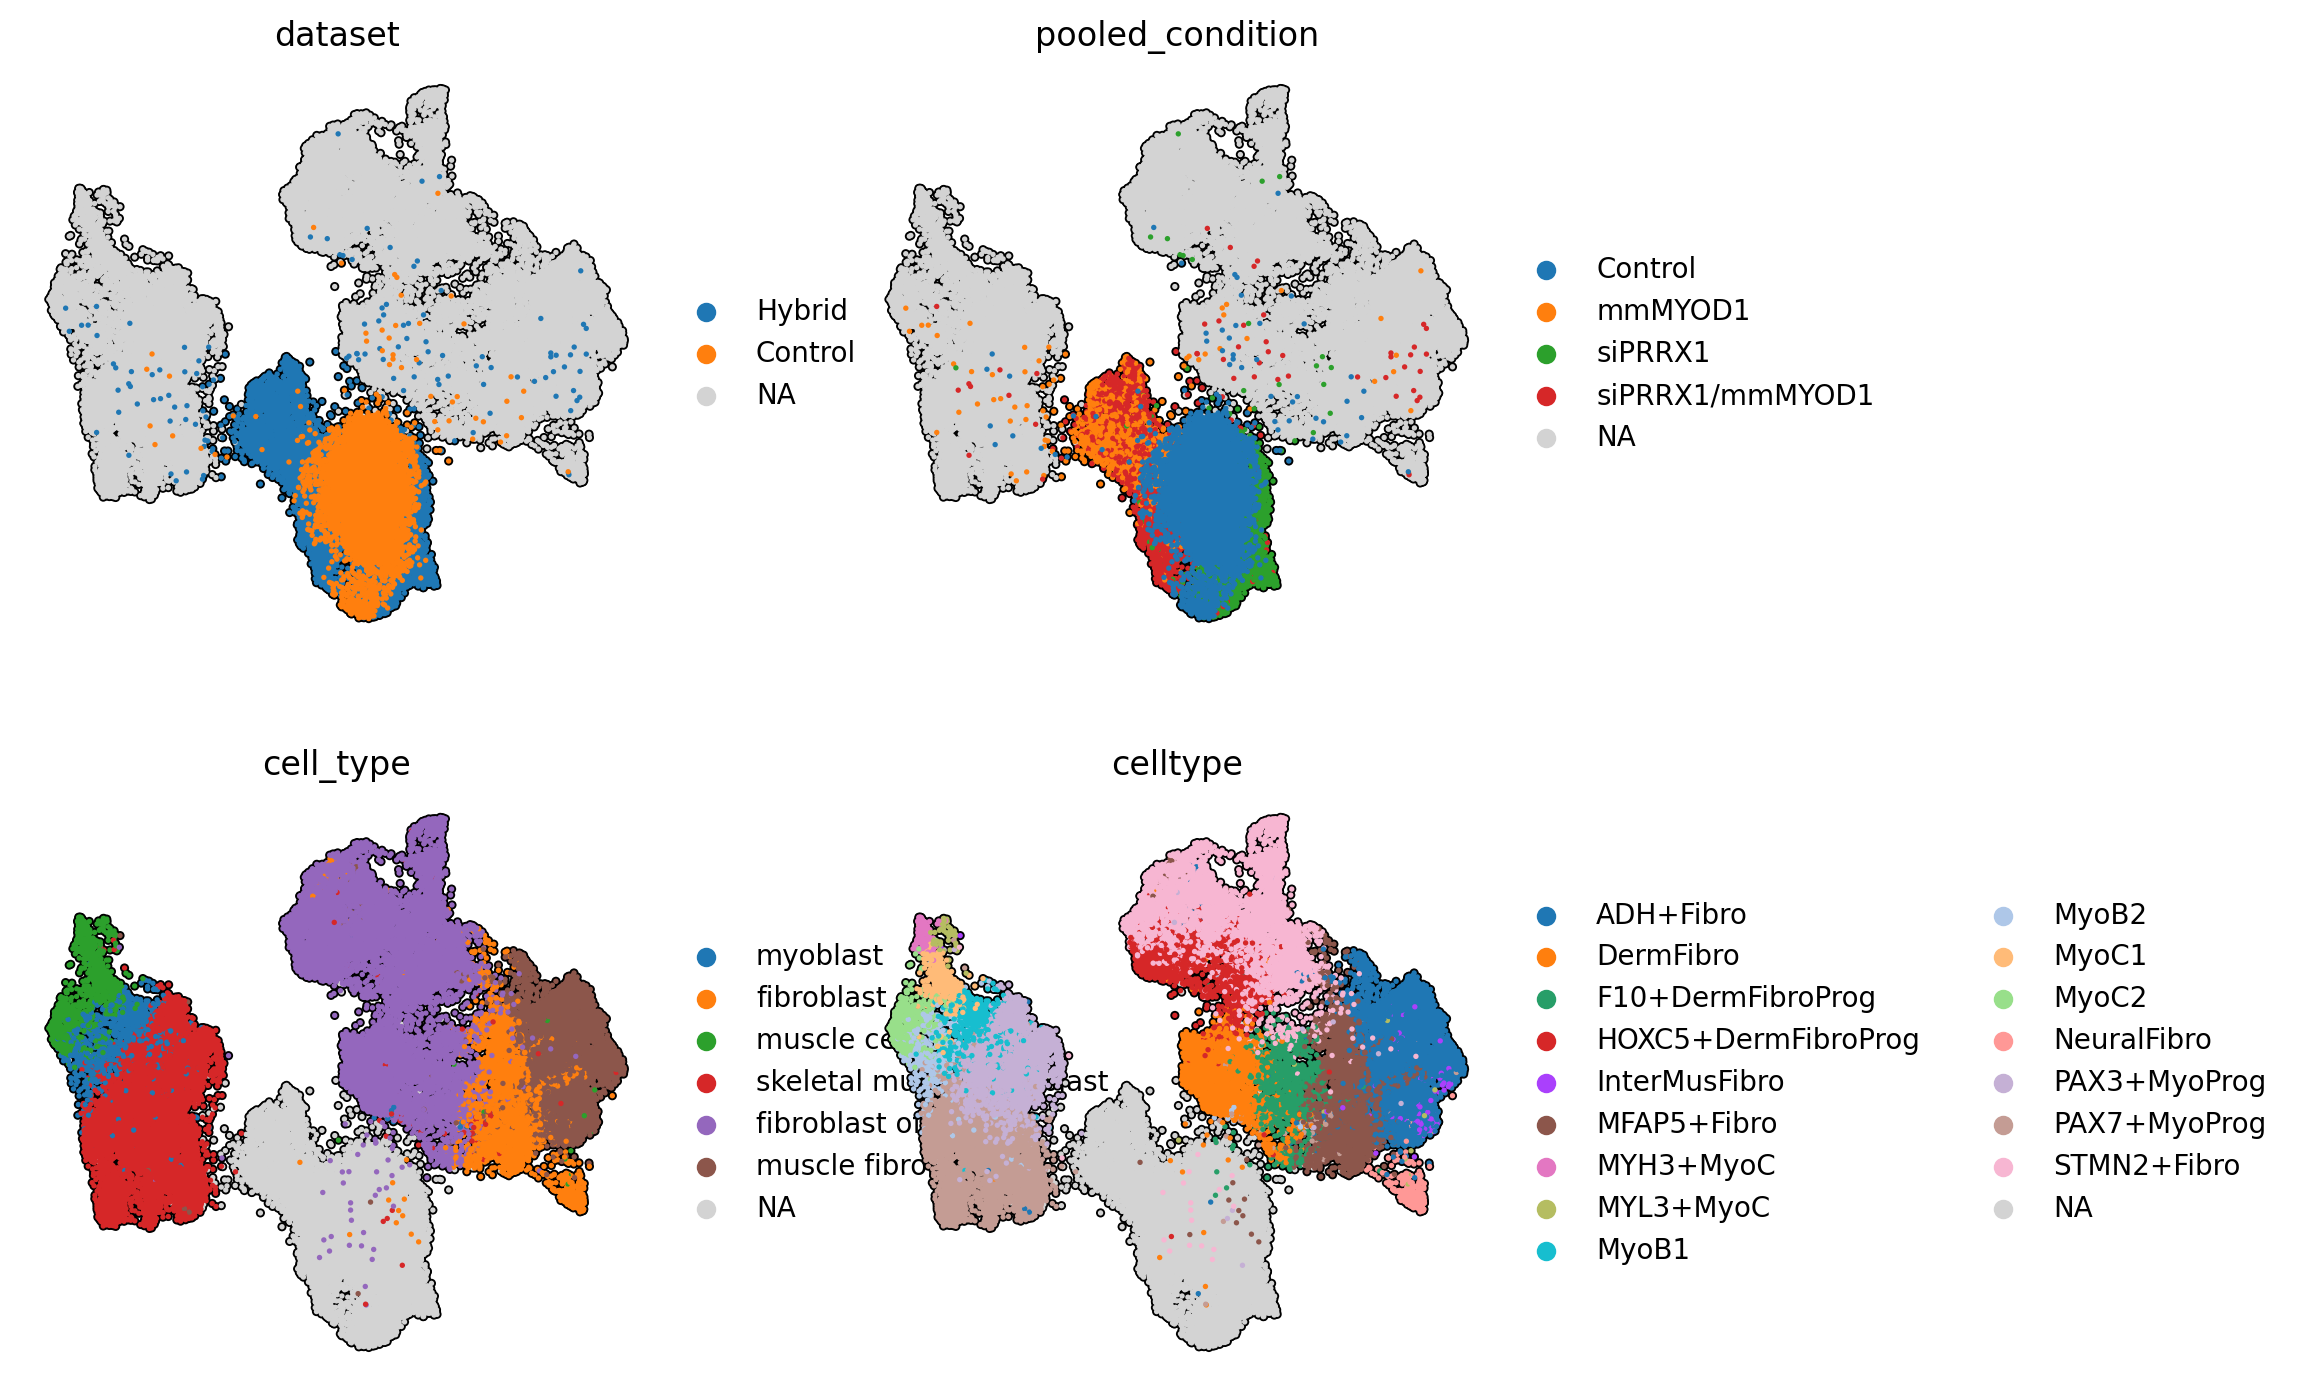

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'cell_type', 'celltype'],
    size=15,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [6]:
adata.obs['atlas_grouping'] = (
    adata.obs['cell_type'].combine_first(adata.obs['pooled_condition'])
)

adata.obs['atlas_grouping'].value_counts()

atlas_grouping
fibroblast of dermis        13233
skeletal muscle myoblast     9804
Control                      6960
muscle fibroblast            6519
fibroblast                   4030
siPRRX1/mmMYOD1              3451
siPRRX1                      3430
mmMYOD1                      2109
muscle cell                  1273
myoblast                     1051
Name: count, dtype: int64

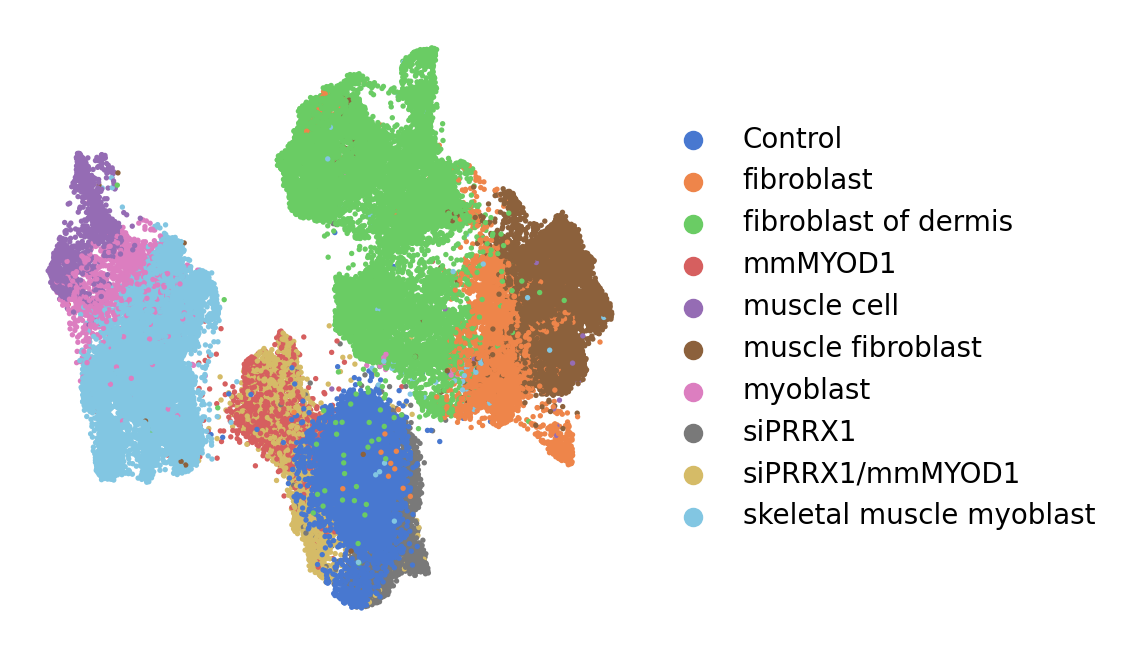

In [17]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='atlas_grouping',
    size=15,
    frameon=False,
    alpha=1,
    palette=sns.color_palette('muted'),
    title='',
    # legend_loc='on data',
)

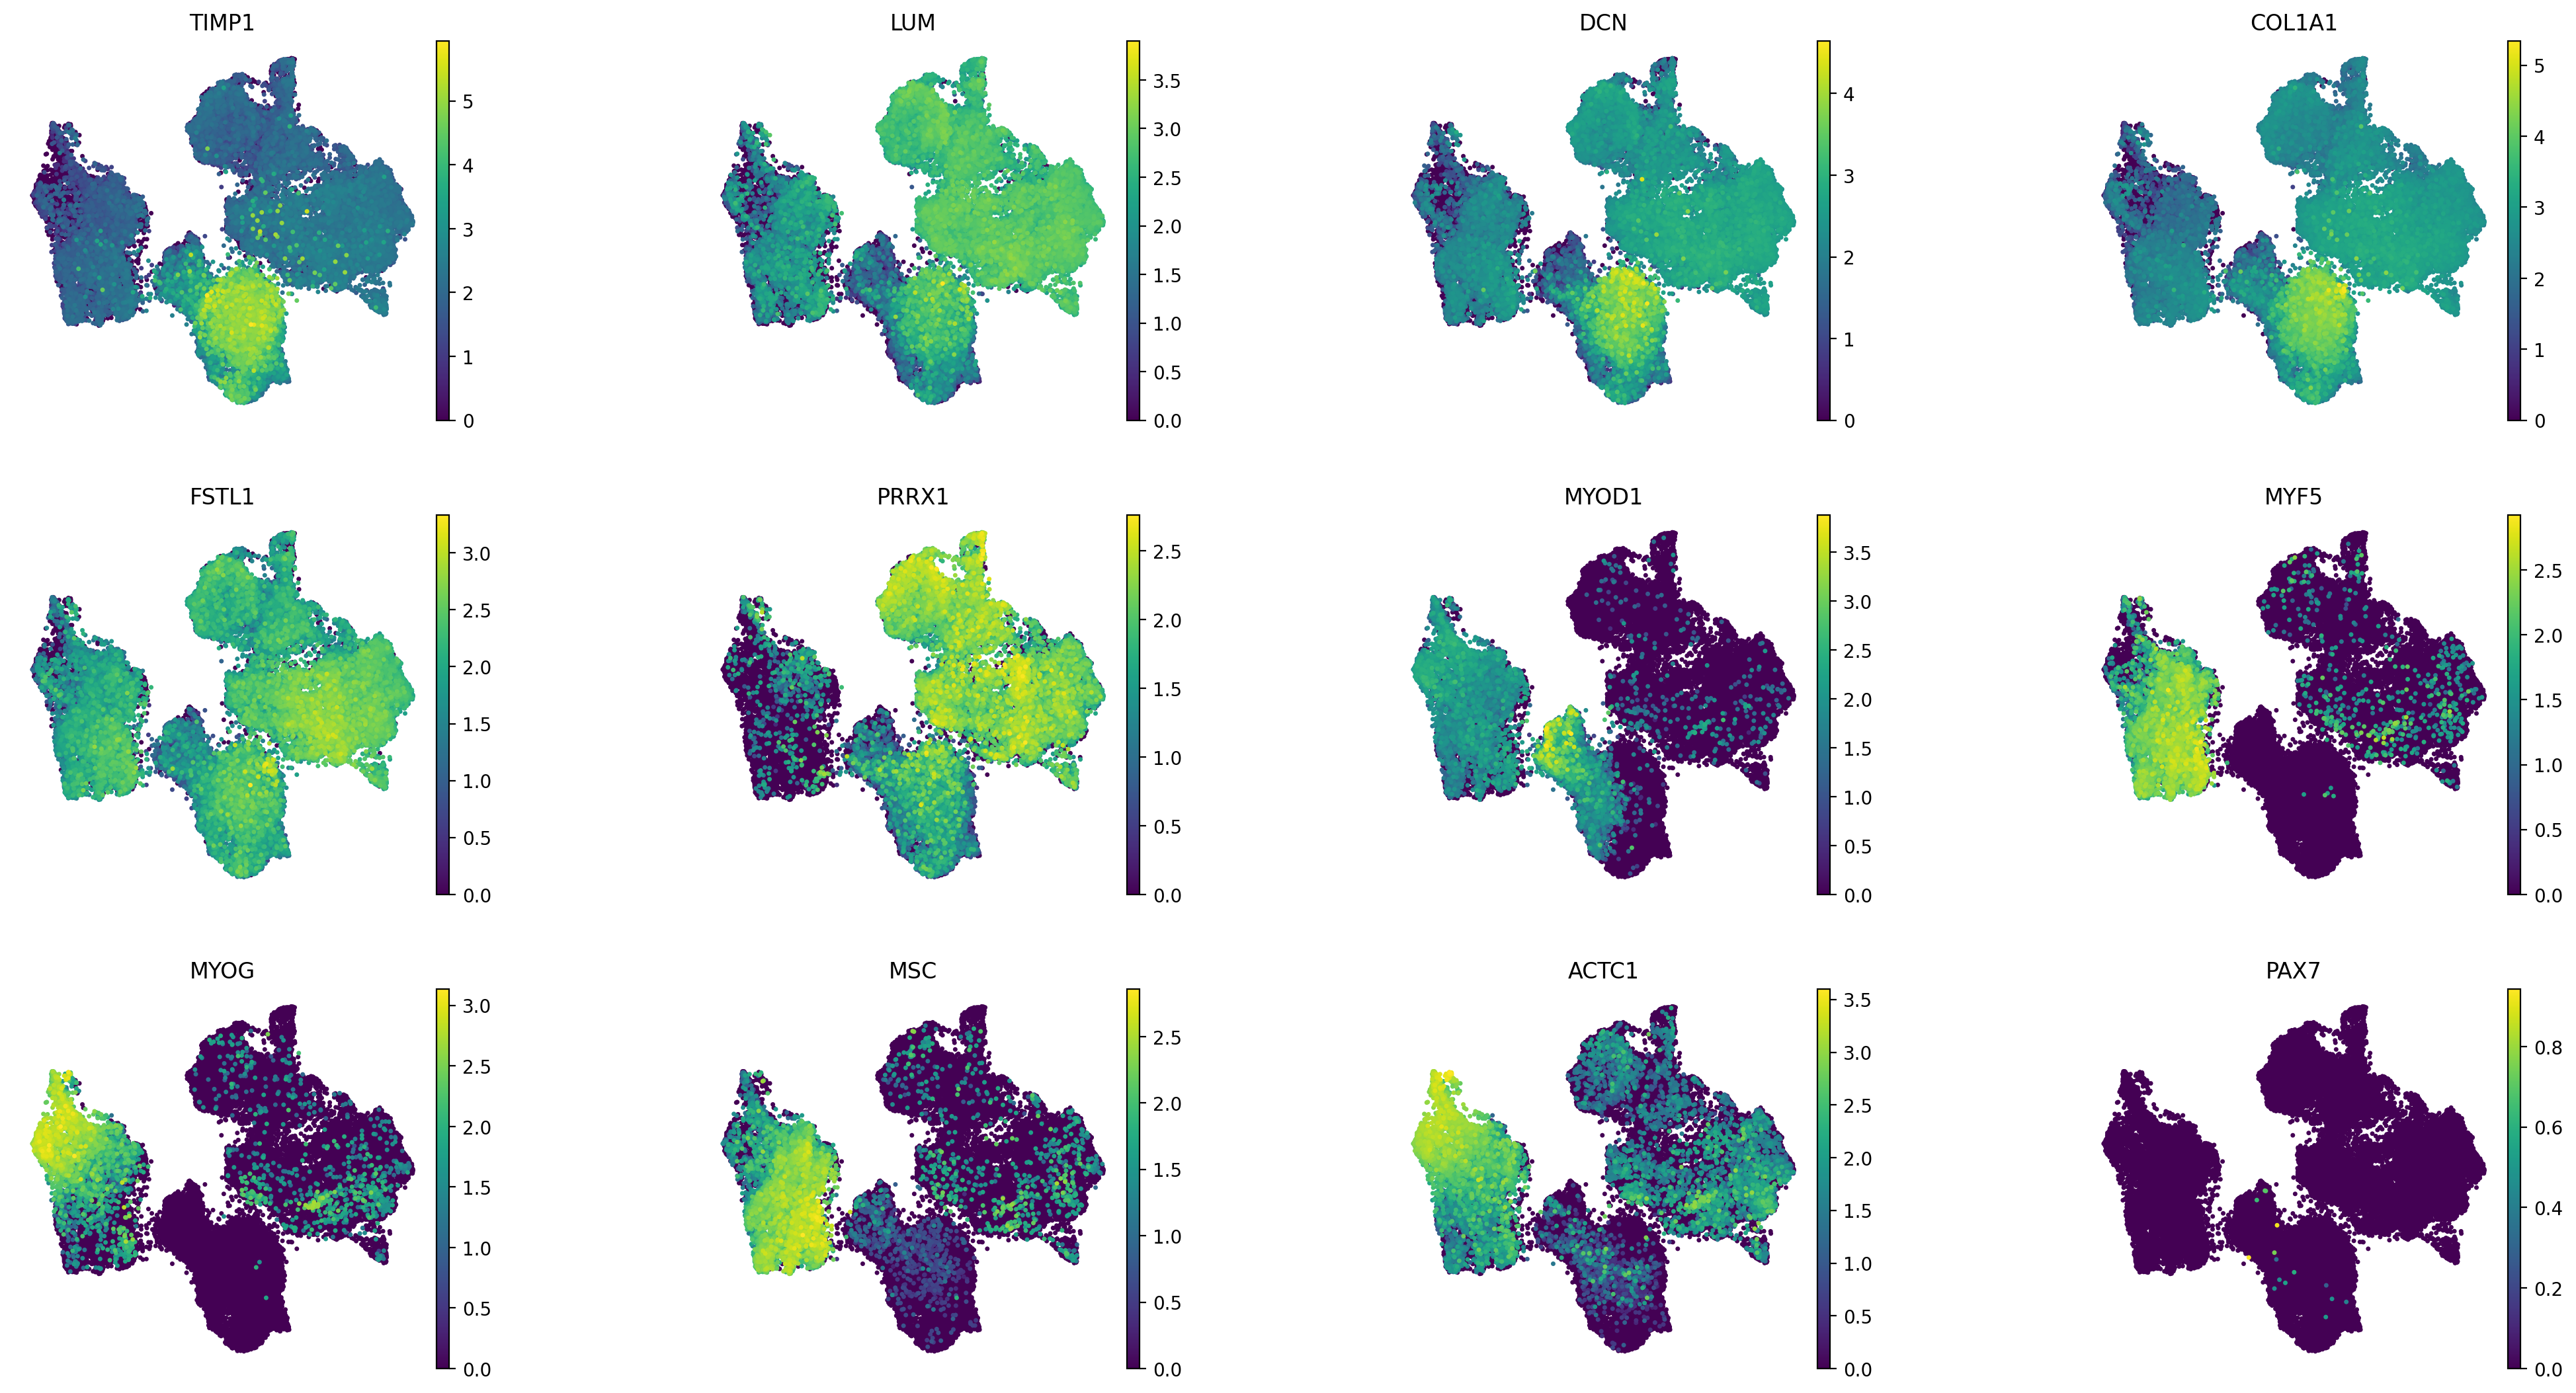

In [36]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

genes = [
    #fibroblast
    'TIMP1', 'LUM', 'DCN', 'COL1A1', 'FSTL1', 'PRRX1', 
    # muscle
    'MYOD1', 'MYF5', 'MYOG', 'MSC', 'ACTC1', 'CKMM', 'PAX7',
]

genes_to_plot = [g for g in genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=genes_to_plot,
    size=25,
    ncols=4,
    alpha=1,
    use_raw=False,
    layer='log_norm',
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [25]:
df = adata.uns['scvi'].copy()

df = df.T.reset_index(names='gene_name')

df.head()

,gene_name,AAACCAAAGCAACTGC_hybrid,AAACCAAAGTAGGGCA_hybrid,AAACCAAAGTCTAGGC_hybrid,AAACCATTCACGTAAT_hybrid,AAACCATTCAGGCAGA_hybrid,AAACCATTCCGTAATG_hybrid,AAACCCGCACCATAGG_hybrid,AAACCCGCATCCAATT_hybrid,AAACCCTGTAACGACA_hybrid,...,TTGGAACTCCAAGTAC-WSSS_THYst9384958,TTGTAGGGTAGCCTCG-WSSS_THYst9384958,TTTACTGGTCTCGTTC-WSSS_THYst9384958,TTTACTGGTTGGTAAA-WSSS_THYst9384958,TTTCCTCGTTTACTCT-WSSS_THYst9384958,TTTGCGCCACGGTGTC-WSSS_THYst9384958,TTTGCGCTCGGCGCAT-WSSS_THYst9384958,TTTGGTTAGTGGGTTG-WSSS_THYst9384958,TTTGGTTCAAGTCTAC-WSSS_THYst9384958,TTTGGTTGTCGTGGCT-WSSS_THYst9384958
0,A2M,0.000016,0.000006,0.000004,0.000011,0.000017,0.000006,0.000007,0.000009,0.000020,...,0.000001,5.983004e-06,0.000036,0.000003,0.000015,0.000028,0.000003,1.202580e-05,0.000008,0.000015
1,A4GALT,0.000016,0.000043,0.000018,0.000023,0.000031,0.000021,0.000033,0.000049,0.000038,...,0.000001,8.276158e-07,0.000028,0.000001,0.000001,0.000002,0.000002,6.557889e-07,0.000002,0.000002
2,AACS,0.000095,0.000092,0.000070,0.000120,0.000074,0.000070,0.000069,0.000076,0.000115,...,0.000299,2.980149e-04,0.000196,0.000322,0.000304,0.000302,0.000340,2.333341e-04,0.000284,0.000270
3,AADAT,0.000014,0.000056,0.000016,0.000022,0.000020,0.000019,0.000025,0.000018,0.000026,...,0.000159,1.863802e-04,0.000066,0.000185,0.000279,0.000190,0.000241,2.258719e-04,0.000238,0.000229
4,AARS2,0.000064,0.000075,0.000044,0.000061,0.000057,0.000034,0.000041,0.000061,0.000046,...,0.000120,1.337032e-04,0.000052,0.000153,0.000174,0.000159,0.000165,1.559844e-04,0.000143,0.000169


In [26]:
scvi_genes = df['gene_name'].unique()
print(len(scvi_genes))

5500


['TIMP1', 'DCN', 'COL1A1', 'MYOD1', 'MYF5', 'MYOG', 'MSC', 'ACTC1']


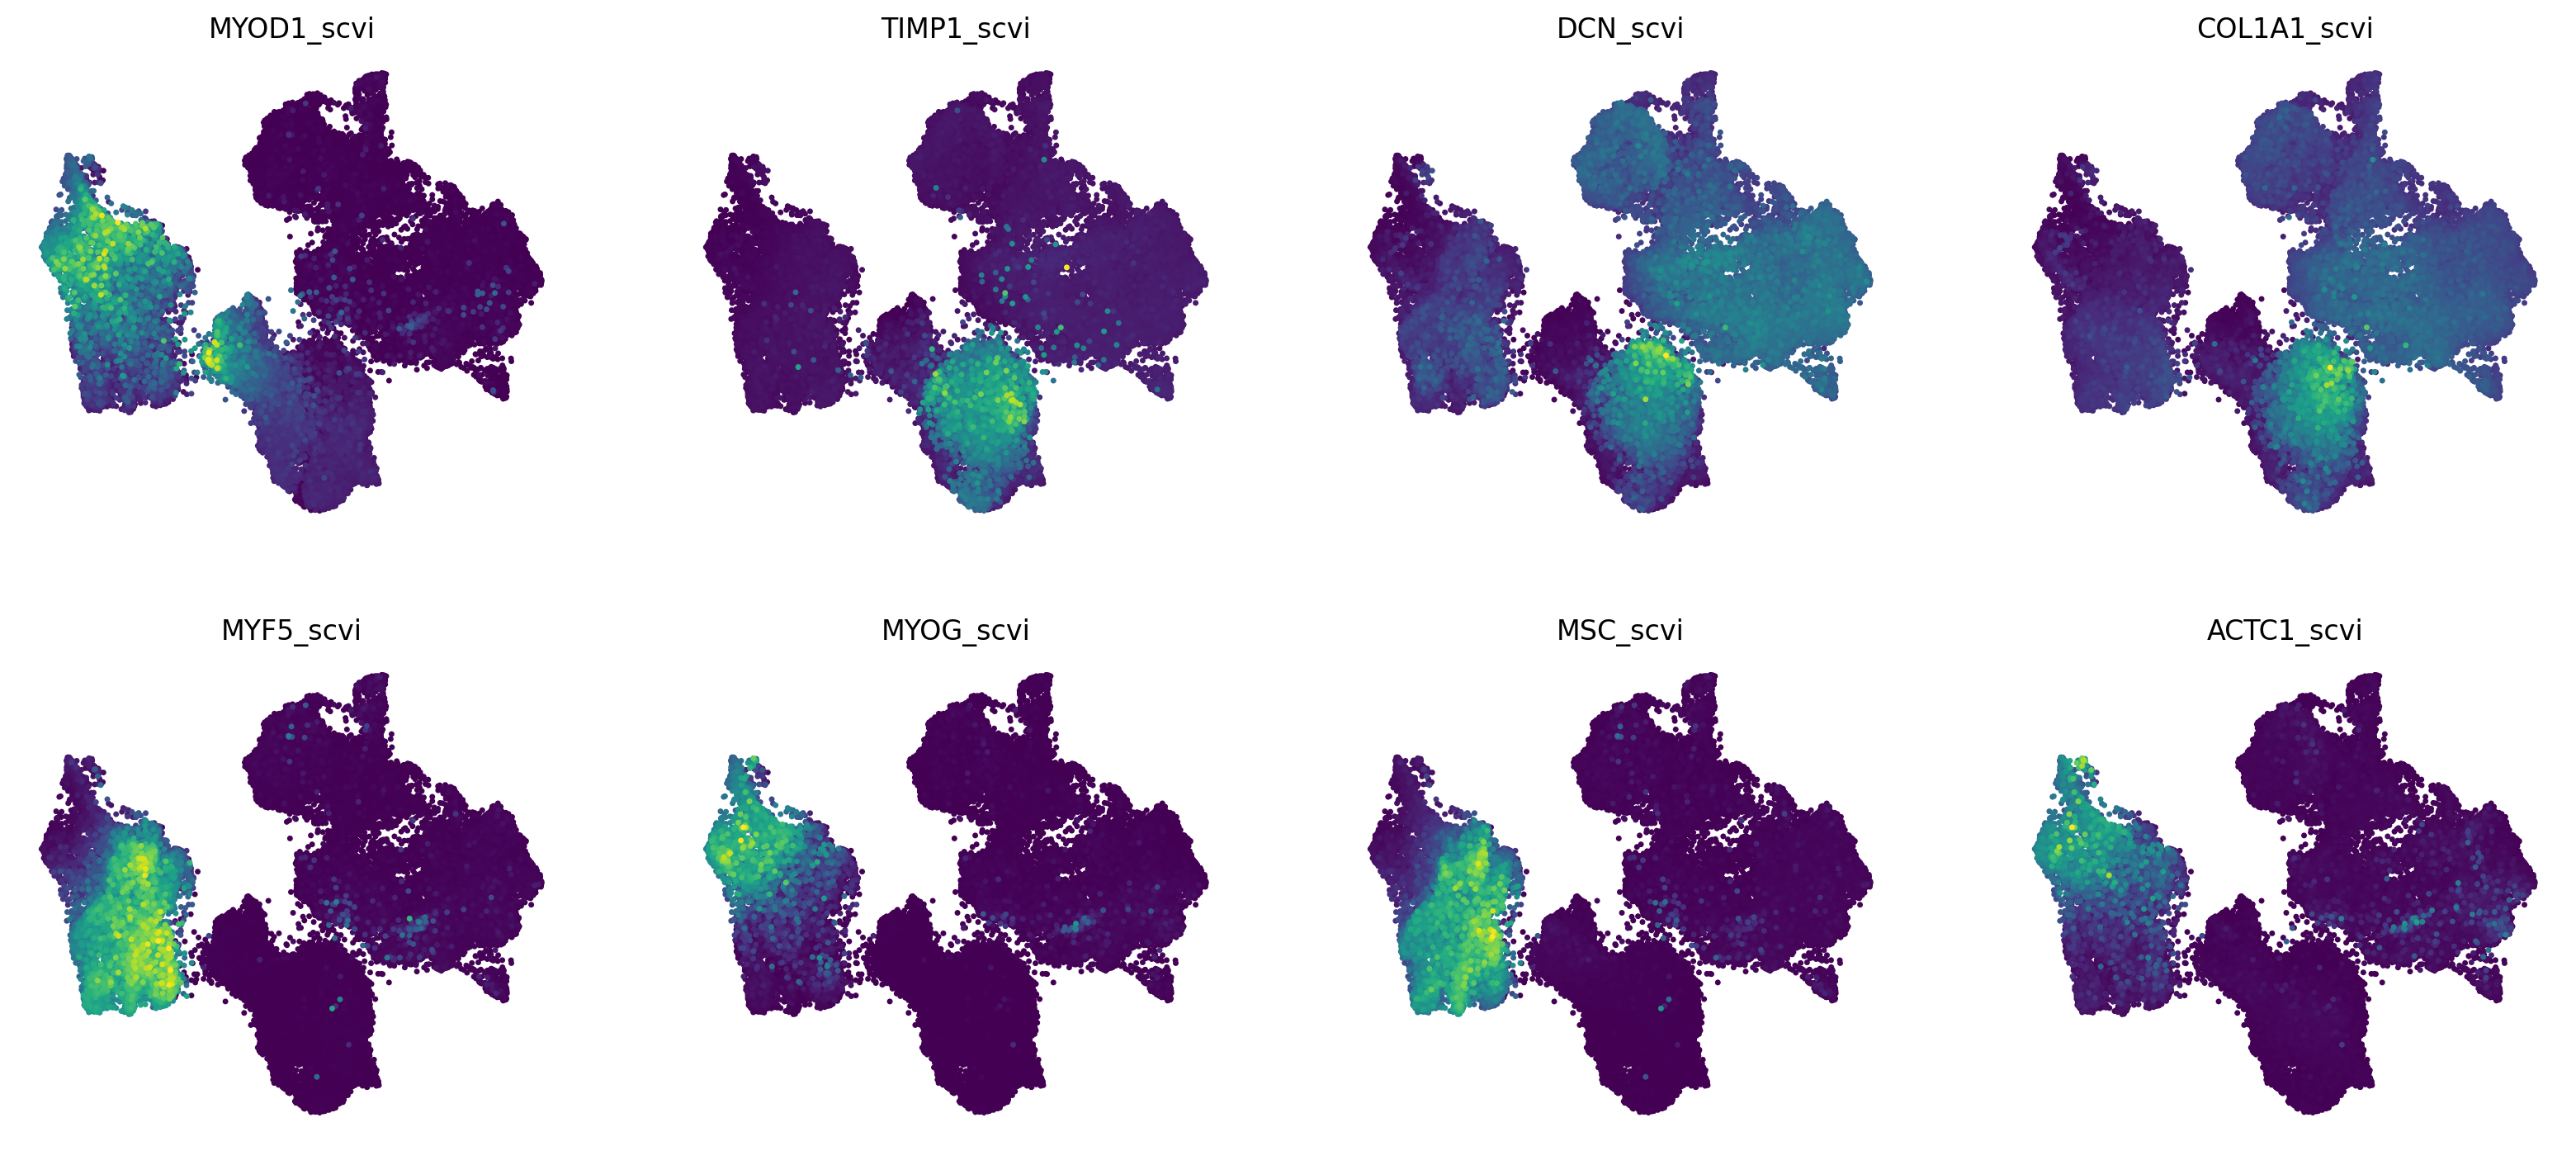

In [35]:
genes = [
    #fibroblast
    'TIMP1', 'LUM', 'DCN', 'COL1A1', 'FSTL1', 'PRRX1', 
    # muscle
    'MYOD1', 'MYF5', 'MYOG', 'MSC', 'ACTC1', 'CKMM', 'PAX7',
]

genes_to_plot = [g for g in genes if g in scvi_genes]
print(genes_to_plot)


for gene in genes_to_plot:
    adata.obs[f"{gene}_scvi"] = adata.uns['scvi'][gene]
    
    
colors = [g for g in adata.obs.columns if g.endswith('_scvi')]
colors

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=colors,
    ncols=4,
    size=25,
    frameon=False,
    use_raw=False,
    alpha=1,
    colorbar_loc=None,
    # palette=sns.color_palette('muted'),
    # title='',
    # legend_loc='on data',
)

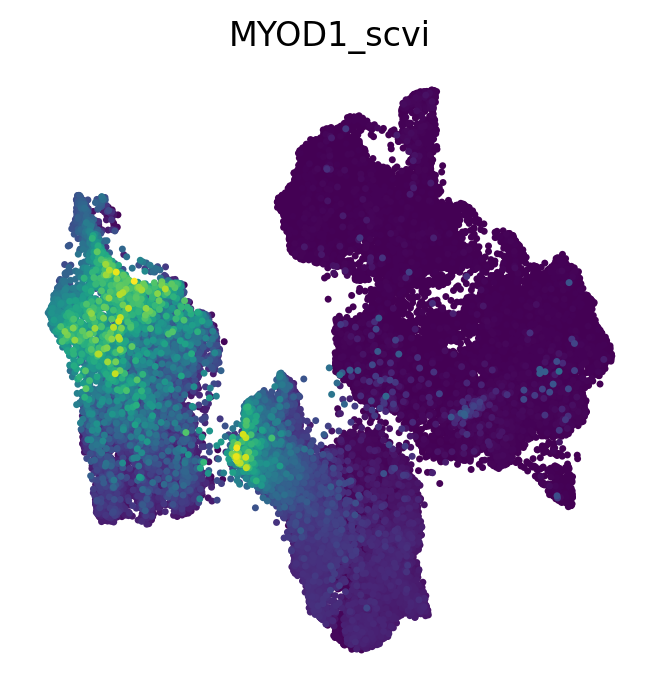

In [21]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4


color = 'MYOD1'
adata.obs[f"{color}_scvi"] = adata.uns['scvi'][color]

sc.pl.umap(
    adata,
    color=f"{color}_scvi",
    size=25,
    frameon=False,
    use_raw=False,
    alpha=1,
    colorbar_loc=None,
    # palette=sns.color_palette('muted'),
    # title='',
    # legend_loc='on data',
)

In [27]:
adata

AnnData object with n_obs × n_vars = 51860 × 26720
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

# DGE

In [29]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    
    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [28]:
# all groups vs each other
sc.tl.rank_genes_groups(
    adata, 
    groupby="atlas_grouping",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='atlas_deg',
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='atlas_deg',
)
print(deg.shape)

(267200, 8)


In [30]:
sig = get_significant_DEGs(deg)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 15738



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
0,Control,MT-ATP8,134.411148,5.660514,0.0,0.0,1.0,0.292405,5.660514
1,Control,OOEP-AS1,132.052917,5.367719,0.0,0.0,1.0,0.198285,5.367719
2,Control,TIMP1,131.232956,4.097699,0.0,0.0,1.0,0.744967,4.097699
3,Control,RPLP1,131.160263,2.376771,0.0,0.0,1.0,0.999532,2.376771
4,Control,RPS29,130.733902,1.283970,0.0,0.0,1.0,0.997394,1.283970


In [31]:
sig.groupby('group', observed=True)[['group', 'names', 'scores', 'logfoldchanges']].head()

,group,names,scores,logfoldchanges
0,Control,MT-ATP8,134.411148,5.660514
1,Control,OOEP-AS1,132.052917,5.367719
2,Control,TIMP1,131.232956,4.097699
3,Control,RPLP1,131.160263,2.376771
4,Control,RPS29,130.733902,1.283970
26720,fibroblast,OGN,79.449280,3.462420
26721,fibroblast,FSTL1,73.152962,1.314698
26722,fibroblast,PTN,72.823051,2.087286
26723,fibroblast,POSTN,72.264572,3.181497
26724,fibroblast,DLK1,71.421303,3.009964


In [ ]:
genes = [
    #fibroblast
    'TIMP1', 'LUM', 'DCN', 'COL1A1', 'FSTL1', 'PRRX1',
    # muscle
    'MYOD1', 'MYF5', 'MYOG', 'MSC', 'ACTC1', 'CKMM', 'PAX7',
]